Для прогноза я выбрал метод Хольта-Винтерса, потому что:
- он достаточен для базового прогноза, т.к. данные имеют чёткую годовую сезонность и умеренный тренд
- не нужно прогнозировать внешние признаки (c1, cat1) или заполнять их средними, особенно, если неизвестно, что это такое; это может вности дополнительную неопределённость
- этот метод достаточно прост, его легко объяснить заказчику: модель выделяет тренд и сезонность, результат понятен


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [53]:
df = pd.read_csv('newborns_stats.csv')
df.head()

,year,month,c1,cat1,target
0,2015,1,NaN,0,12346
1,2015,2,NaN,0,11210
2,2015,3,40.045,0,12237
3,2015,4,39.860,0,12685
4,2015,5,42.367,1,12881


In [54]:
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
df = df.sort_values('date').set_index('date')
df.head()

,year,month,c1,cat1,target
date,,,,,
2015-01-01,2015,1,NaN,0,12346
2015-02-01,2015,2,NaN,0,11210
2015-03-01,2015,3,40.045,0,12237
2015-04-01,2015,4,39.860,0,12685
2015-05-01,2015,5,42.367,1,12881


In [55]:
ts = df['target'].asfreq('MS')
ts.head()

date
2015-01-01    12346
2015-02-01    11210
2015-03-01    12237
2015-04-01    12685
2015-05-01    12881
Freq: MS, Name: target, dtype: int64

In [56]:
train = ts.iloc[:-24]
train

date
2015-01-01    12346
2015-02-01    11210
2015-03-01    12237
2015-04-01    12685
2015-05-01    12881
              ...  
2022-11-01     9653
2022-12-01    10195
2023-01-01     9726
2023-02-01     8885
2023-03-01    10281
Freq: MS, Name: target, Length: 99, dtype: int64

In [57]:
test = ts.iloc[-24:]
test

date
2023-04-01     9404
2023-05-01     9929
2023-06-01    10443
2023-07-01    10844
2023-08-01    10893
2023-09-01     9778
2023-10-01    10427
2023-11-01     9739
2023-12-01     9771
2024-01-01     9661
2024-02-01     9055
2024-03-01     8915
2024-04-01     9354
2024-05-01    10424
2024-06-01    10398
2024-07-01    11413
2024-08-01    10995
2024-09-01     9947
2024-10-01    10629
2024-11-01     9751
2024-12-01     9225
2025-01-01     8927
2025-02-01     8152
2025-03-01     6611
Freq: MS, Name: target, dtype: int64

In [58]:
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit(optimized=True)
fit

In [59]:
forecast_test = fit.forecast(steps=len(test))
forecast_test.head()

2023-04-01     9998.814425
2023-05-01    10433.322624
2023-06-01    11024.612164
2023-07-01    11608.216813
2023-08-01    11367.057857
Freq: MS, dtype: float64

In [60]:
mae = mean_absolute_error(test, forecast_test)
mae

459.3000027070346

In [61]:
rmse = np.sqrt(mean_squared_error(test, forecast_test))
rmse

721.0168623337879

In [62]:
mape = np.mean(np.abs((test - forecast_test) / test)) * 100
mape

5.2905691553771375

In [63]:
final_model = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12)
final_fit = final_model.fit(optimized=True)
forecast_future = final_fit.forecast(steps=12)

In [64]:
forecast_future

2025-04-01    7678.119214
2025-05-01    8203.559028
2025-06-01    8726.962707
2025-07-01    9319.666495
2025-08-01    9091.735656
2025-09-01    8160.191985
2025-10-01    8398.621825
2025-11-01    7681.465254
2025-12-01    7576.505348
2026-01-01    7298.047547
2026-02-01    6535.156501
2026-03-01    7234.788415
Freq: MS, dtype: float64

In [65]:
future_dates = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
forecast_series = pd.Series(forecast_future, index=future_dates, name='forecast')
forecast_series.head()

2025-04-01    7678.119214
2025-05-01    8203.559028
2025-06-01    8726.962707
2025-07-01    9319.666495
2025-08-01    9091.735656
Freq: MS, Name: forecast, dtype: float64

In [66]:
print(f'Оценка на тестовом периоде\nпоследние 24 месяца\n')
print(f'MAE = {mae:.0f}')
print(f'RMSE = {rmse:.0f}')
print(f'MAPE = {mape:.1f}%')

Оценка на тестовом периоде
последние 24 месяца

MAE = 459
RMSE = 721
MAPE = 5.3%


In [67]:
print('\nПрогноз на 12 месяцев\nапрель 2025 – март 2026\n')
print(forecast_series.round(0))


Прогноз на 12 месяцев
апрель 2025 – март 2026

2025-04-01    7678.0
2025-05-01    8204.0
2025-06-01    8727.0
2025-07-01    9320.0
2025-08-01    9092.0
2025-09-01    8160.0
2025-10-01    8399.0
2025-11-01    7681.0
2025-12-01    7577.0
2026-01-01    7298.0
2026-02-01    6535.0
2026-03-01    7235.0
Freq: MS, Name: forecast, dtype: float64


In [68]:
forecast_df = pd.DataFrame({
    'date': forecast_series.index,
    'target': forecast_series.round(0).values
})
forecast_df.to_csv('forecast_12.csv', index=False)

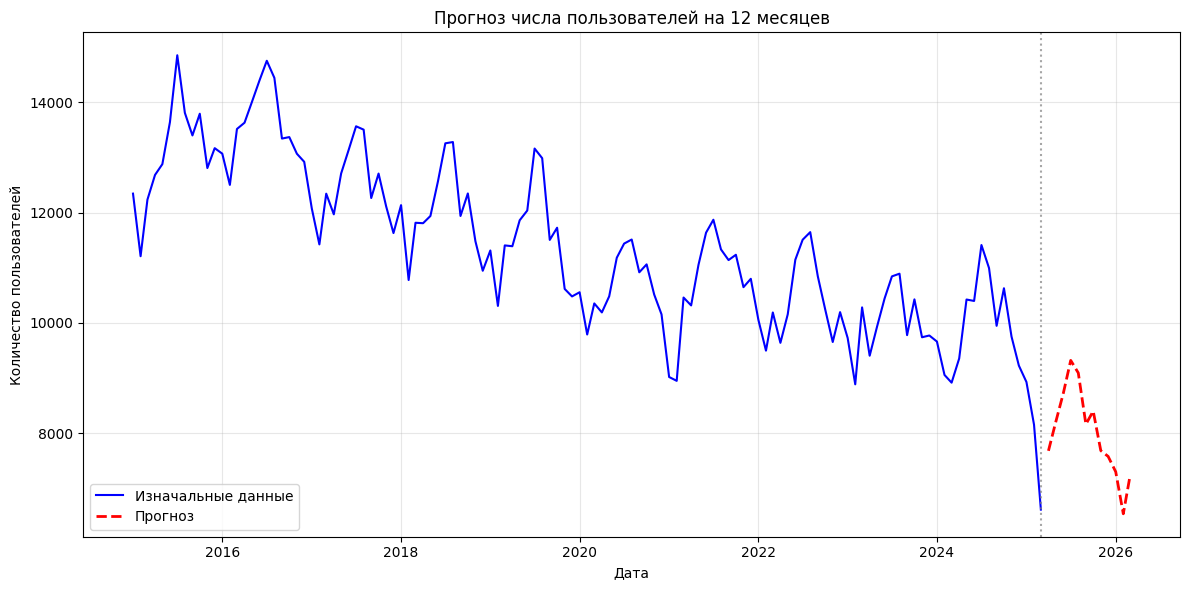

In [69]:
plt.figure(figsize=(12, 6))
plt.plot(ts.index.values, ts.values, label='Изначальные данные', color='blue', linewidth=1.5)
plt.plot(forecast_series.index.values, forecast_series.values,
         label='Прогноз', color='red', linestyle='--', linewidth=2)

plt.axvline(x=ts.index[-1], color='gray', linestyle=':', alpha=0.7)
plt.title('Прогноз числа пользователей на 12 месяцев')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()